# Assignment 3
## Student name: Bhavika Lalwani
## Student id: 25679681

This notebook contains two image captioning architectures:

Model 1: EfficientNet-B0 Encoder (pretrained, frozen) + LSTM Decoder (greedy decoding)

Model 2: EfficientNet-B0 Encoder (pretrained, partially unfrozen) + LSTM Decoder with Bahdanau Attention and Beam Search

Both models are evaluated using BLEU-1 through BLEU-4 on the shared test split produced in Phase 1.

### Installs

In [3]:
import subprocess
subprocess.run(["pip", "install", "nltk", "-q"])
import nltk
nltk.download('punkt', quiet=True)

True

### Imports

In [4]:
import os
import json
import pickle
import random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torchvision.transforms as transforms
import torchvision.models as models

import matplotlib.pyplot as plt
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


### Paths

In [7]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    if level < 4:
        print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/bhavikaaaa
/kaggle/input/datasets/bhavikaaaa/vizwiz-artefacts
/kaggle/input/datasets/bhavikaaaa/vizwiz-val-images


In [5]:
ARTEFACTS_DIR = Path("/kaggle/input/datasets/bhavikaaaa/vizwiz-artefacts/artefacts")
IMAGE_DIR     = Path("/kaggle/input/datasets/bhavikaaaa/vizwiz-val-images/val")
OUTPUT_DIR    = Path("/kaggle/working")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Artefacts dir exists:", ARTEFACTS_DIR.exists())
print("Image dir exists:", IMAGE_DIR.exists())

Artefacts dir exists: True
Image dir exists: True


### Load Artefacts

In [6]:
with open(ARTEFACTS_DIR / "vocab.pkl", "rb") as f:
    vocab_data = pickle.load(f)

VOCAB_SIZE      = vocab_data["vocab_size"]
PAD_IDX         = vocab_data["pad_idx"]
SOS_IDX         = vocab_data["sos_idx"]
EOS_IDX         = vocab_data["eos_idx"]
UNK_IDX         = vocab_data["unk_idx"]
MAX_CAPTION_LEN = vocab_data["max_caption_len"]
stoi            = vocab_data["stoi"]
itos            = vocab_data["itos"]

with open(ARTEFACTS_DIR / "splits.json", "r") as f:
    splits = json.load(f)

train_ids = [int(x) for x in splits["train"]]
val_ids   = [int(x) for x in splits["val"]]
test_ids  = [int(x) for x in splits["test"]]

with open(ARTEFACTS_DIR / "id_to_tokens.json", "r") as f:
    id_to_tokens = {int(k): v for k, v in json.load(f).items()}

# Build image_id -> filename lookup from captions csv
df_captions = pd.read_csv(ARTEFACTS_DIR / "captions_processed.csv")
id_to_filename = dict(zip(df_captions["image_id"], df_captions["file_name"]))

print(f"Vocab size:      {VOCAB_SIZE}")
print(f"Train images:    {len(train_ids)}")
print(f"Val images:      {len(val_ids)}")
print(f"Test images:     {len(test_ids)}")

Vocab size:      3274
Train images:    5425
Val images:      1162
Test images:     1163


### Shared Utilities (used by both models)

In [8]:
def encode_caption(tokens):
    return [SOS_IDX] + [stoi.get(t, UNK_IDX) for t in tokens[:MAX_CAPTION_LEN]] + [EOS_IDX]

def decode_indices(indices):
    special = {PAD_IDX, SOS_IDX, EOS_IDX}
    words = []
    for idx in indices:
        if idx == EOS_IDX:
            break
        if idx not in special and idx < len(itos):
            words.append(itos[idx])
    return " ".join(words)

def compute_bleu(loader, model):
    model.eval()
    hypotheses = []
    references = []

    with torch.no_grad():
        for images, all_captions_batch, _ in tqdm(loader, desc="BLEU eval", leave=False):
            images = images.to(DEVICE)
            preds  = model.generate(images)

            for i, pred_indices in enumerate(preds):
                special = {PAD_IDX, SOS_IDX, EOS_IDX}
                hyp = [itos[idx] for idx in pred_indices
                       if idx not in special and idx < len(itos)]
                hypotheses.append(hyp)

                refs = []
                for cap_tensor in all_captions_batch[i]:
                    ref = [itos[idx] for idx in cap_tensor.tolist()
                           if idx not in (PAD_IDX, SOS_IDX, EOS_IDX) and idx < len(itos)]
                    refs.append(ref)
                references.append(refs)

    b1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0))
    b2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0))
    b3 = corpus_bleu(references, hypotheses, weights=(1/3, 1/3, 1/3, 0))
    b4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25))
    return b1, b2, b3, b4

def show_predictions(dataset, model, title, n=5):
    model.eval()
    indices = random.sample(range(len(dataset)), n)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            image_tensor, all_caps, _ = dataset[idx]
            image_input  = image_tensor.unsqueeze(0).to(DEVICE)
            pred_indices = model.generate(image_input)[0]
            pred_caption = decode_indices(pred_indices)
            ref_caption  = decode_indices(all_caps[0].tolist())

            img = (image_tensor * std + mean).permute(1, 2, 0).clamp(0, 1).numpy()
            ax.imshow(img)
            ax.axis("off")
            ax.set_title(f"Pred: {pred_caption}\nRef:  {ref_caption}", fontsize=7, wrap=True)

    plt.suptitle(title, fontsize=10)
    plt.tight_layout()
    plt.show()

def plot_loss_curves(train_losses, val_losses, title):
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train")
    plt.plot(range(1, len(val_losses) + 1),   val_losses,   label="Val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (per token)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

print("Shared utilities defined.")

Shared utilities defined.


### Dataset and DataLoaders (shared by both models)

In [9]:
class VizWizDataset(Dataset):
    def __init__(self, image_ids, id_to_tokens, id_to_filename, image_dir,
                 transform, training=True):
        self.id_to_tokens   = id_to_tokens
        self.id_to_filename = id_to_filename
        self.image_dir      = Path(image_dir)
        self.transform      = transform
        self.training       = training

        if training:
            self.samples = []
            for iid in image_ids:
                for cap_tokens in id_to_tokens[iid]:
                    self.samples.append((iid, cap_tokens))
        else:
            self.samples = list(image_ids)

    def _load_image(self, iid):
        fname = self.id_to_filename[iid]
        path  = self.image_dir / fname
        return self.transform(Image.open(path).convert("RGB"))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        if self.training:
            iid, tokens = self.samples[idx]
            image   = self._load_image(iid)
            encoded = encode_caption(tokens)
            return image, torch.tensor(encoded, dtype=torch.long), torch.tensor(len(encoded), dtype=torch.long)
        else:
            iid   = self.samples[idx]
            image = self._load_image(iid)
            all_caps = [torch.tensor(encode_caption(t), dtype=torch.long)
                        for t in self.id_to_tokens[iid]]
            all_lens = torch.tensor([len(c) for c in all_caps], dtype=torch.long)
            return image, all_caps, all_lens


def collate_train(batch):
    images, captions, lengths = zip(*batch)
    return (torch.stack(images),
            pad_sequence(captions, batch_first=True, padding_value=PAD_IDX),
            torch.stack(lengths))

def collate_eval(batch):
    images, all_captions, all_lengths = zip(*batch)
    return torch.stack(images), list(all_captions), torch.stack(all_lengths)


BATCH_SIZE  = 32
NUM_WORKERS = 0

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_dataset = VizWizDataset(train_ids, id_to_tokens, id_to_filename, IMAGE_DIR, train_transform, training=True)
val_dataset   = VizWizDataset(val_ids,   id_to_tokens, id_to_filename, IMAGE_DIR, eval_transform,  training=False)
test_dataset  = VizWizDataset(test_ids,  id_to_tokens, id_to_filename, IMAGE_DIR, eval_transform,  training=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          collate_fn=collate_train, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_eval)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_eval)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 847
Val batches:   37
Test batches:  37


### Shared Training Loop

In [10]:
def train_model(model, train_loader, val_loader, epochs, lr, save_path):
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    train_losses, val_losses = [], []
    best_val_loss = float("inf")

    for epoch in range(1, epochs + 1):
        # Training
        model.train()
        total_loss, total_tokens = 0.0, 0
        for images, captions, lengths in tqdm(train_loader, desc=f"Epoch {epoch} train", leave=False):
            images   = images.to(DEVICE)
            captions = captions.to(DEVICE)
            inputs   = captions[:, :-1]
            targets  = captions[:, 1:]

            logits = model(images, inputs, lengths)
            B, T, V = logits.shape
            loss = criterion(logits.reshape(B * T, V), targets.reshape(B * T))

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            non_pad       = (targets != PAD_IDX).sum().item()
            total_loss   += loss.item() * non_pad
            total_tokens += non_pad

        train_loss = total_loss / total_tokens

        # Validation
        model.eval()
        total_loss, total_tokens = 0.0, 0
        with torch.no_grad():
            for images, all_captions_batch, _ in tqdm(val_loader, desc=f"Epoch {epoch} val", leave=False):
                images = images.to(DEVICE)
                
                captions = pad_sequence(
                    [all_captions_batch[i][0] for i in range(len(all_captions_batch))],
                    batch_first=True, padding_value=PAD_IDX
                ).to(DEVICE)
                lengths  = torch.tensor([len(all_captions_batch[i][0])
                                         for i in range(len(all_captions_batch))], dtype=torch.long)
                inputs  = captions[:, :-1]
                targets = captions[:, 1:]

                logits = model(images, inputs, lengths)
                B, T, V = logits.shape
                loss = criterion(logits.reshape(B * T, V), targets.reshape(B * T))

                non_pad       = (targets != PAD_IDX).sum().item()
                total_loss   += loss.item() * non_pad
                total_tokens += non_pad

        val_loss = total_loss / total_tokens
        scheduler.step()

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f"Epoch {epoch:02d}/{epochs}  train: {train_loss:.4f}  val: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            print(f"  -> Checkpoint saved (val_loss: {best_val_loss:.4f})")

    return train_losses, val_losses

print("Training loop defined.")

Training loop defined.


## Phase 2

## Model 1: EfficientNet-B0 + LSTM

### Encoder (Model 1)

In [11]:
class EfficientNetEncoder(nn.Module):
    """
    EfficientNet-B0 pre-trained on ImageNet. The classifier head is removed
    and replaced with a linear projection from 1280 to embed_dim.
    The backbone is fully frozen so only the projection is trained in Model 1.
    EfficientNet was chosen over ResNet because it achieves comparable accuracy
    with significantly fewer parameters, which is beneficial given our
    moderately sized training set of 5,400 images.
    """
    def __init__(self, embed_dim=256):
        super().__init__()
        base          = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.backbone = base.features
        self.pool     = nn.AdaptiveAvgPool2d((1, 1))
        self.proj     = nn.Linear(1280, embed_dim)
        self.dropout  = nn.Dropout(0.3)

        for param in self.backbone.parameters():
            param.requires_grad = False

    def forward(self, images):
        x = self.backbone(images)   # (B, 1280, 7, 7)
        x = self.pool(x).flatten(1) # (B, 1280)
        x = self.dropout(x)
        x = self.proj(x)            # (B, embed_dim)
        return x

## Decoder (Model 1)

In [12]:
class LSTMDecoder(nn.Module):
    """
    Single-layer LSTM decoder with teacher forcing during training.
    The encoder feature vector is used to initialise both the hidden
    and cell states via learned linear projections. At each decoding
    step the LSTM receives the embedded previous token and outputs a
    distribution over the full vocabulary.
    Greedy decoding is used at inference time.
    """
    def __init__(self, embed_dim=256, hidden_dim=512,
                 vocab_size=VOCAB_SIZE, dropout=0.3):
        super().__init__()
        self.embed   = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm    = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc_out  = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.init_h  = nn.Linear(embed_dim, hidden_dim)
        self.init_c  = nn.Linear(embed_dim, hidden_dim)

    def _init_hidden(self, encoder_out):
        h = torch.tanh(self.init_h(encoder_out)).unsqueeze(0)
        c = torch.tanh(self.init_c(encoder_out)).unsqueeze(0)
        return h, c

    def forward(self, encoder_out, captions, lengths):
        emb        = self.dropout(self.embed(captions))
        h, c       = self._init_hidden(encoder_out)
        out, _     = self.lstm(emb, (h, c))
        logits     = self.fc_out(self.dropout(out))
        return logits

    def greedy_decode(self, encoder_out, max_len=MAX_CAPTION_LEN):
        B      = encoder_out.size(0)
        h, c   = self._init_hidden(encoder_out)
        token  = torch.full((B, 1), SOS_IDX, dtype=torch.long, device=encoder_out.device)
        result = [[] for _ in range(B)]
        done   = [False] * B

        for _ in range(max_len):
            emb         = self.embed(token)
            out, (h, c) = self.lstm(emb, (h, c))
            predicted   = self.fc_out(out.squeeze(1)).argmax(dim=1)

            for i in range(B):
                if not done[i]:
                    if predicted[i].item() == EOS_IDX:
                        done[i] = True
                    else:
                        result[i].append(predicted[i].item())

            if all(done):
                break
            token = predicted.unsqueeze(1)

        return result

### Model 1 Assembly and Parameter Count

In [13]:
class Model1(nn.Module):
    """EfficientNet-B0 encoder + single-layer LSTM decoder (no attention)."""
    def __init__(self, embed_dim=256, hidden_dim=512,
                 vocab_size=VOCAB_SIZE, dropout=0.3):
        super().__init__()
        self.encoder = EfficientNetEncoder(embed_dim=embed_dim)
        self.decoder = LSTMDecoder(embed_dim=embed_dim, hidden_dim=hidden_dim,
                                   vocab_size=vocab_size, dropout=dropout)

    def forward(self, images, captions, lengths):
        return self.decoder(self.encoder(images), captions, lengths)

    def generate(self, images, max_len=MAX_CAPTION_LEN):
        return self.decoder.greedy_decode(self.encoder(images), max_len)


M1_EMBED_DIM  = 256
M1_HIDDEN_DIM = 512
M1_DROPOUT    = 0.3

model1 = Model1(embed_dim=M1_EMBED_DIM, hidden_dim=M1_HIDDEN_DIM,
                dropout=M1_DROPOUT).to(DEVICE)

total     = sum(p.numel() for p in model1.parameters())
trainable = sum(p.numel() for p in model1.parameters() if p.requires_grad)
print(f"Model 1 — total params:     {total:,}")
print(f"Model 1 — trainable params: {trainable:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 215MB/s]


Model 1 — total params:     8,693,318
Model 1 — trainable params: 4,685,770


Train Model 1

In [14]:
M1_EPOCHS    = 15
M1_LR        = 3e-4
M1_SAVE_PATH = OUTPUT_DIR / "model1_best.pt"

m1_train_losses, m1_val_losses = train_model(
    model1, train_loader, val_loader,
    epochs=M1_EPOCHS, lr=M1_LR, save_path=M1_SAVE_PATH
)

Epoch 01/15  train: 4.2349  val: 3.5203
  -> Checkpoint saved (val_loss: 3.5203)


Epoch 02/15  train: 3.5771  val: 3.2147
  -> Checkpoint saved (val_loss: 3.2147)


Epoch 03/15  train: 3.3374  val: 3.0679
  -> Checkpoint saved (val_loss: 3.0679)


Epoch 04/15  train: 3.1782  val: 2.9830
  -> Checkpoint saved (val_loss: 2.9830)


Epoch 05/15  train: 3.0609  val: 2.9171
  -> Checkpoint saved (val_loss: 2.9171)


...

Epoch 11/15  train: 2.7397  val: 2.8131
  -> Checkpoint saved (val_loss: 2.8131)


Epoch 12/15  train: 2.7188  val: 2.8109
  -> Checkpoint saved (val_loss: 2.8109)


Epoch 13/15  train: 2.7010  val: 2.8030
  -> Checkpoint saved (val_loss: 2.8030)


Epoch 14/15  train: 2.6855  val: 2.8003
  -> Checkpoint saved (val_loss: 2.8003)


Epoch 15/15  train: 2.6709  val: 2.7959
  -> Checkpoint saved (val_loss: 2.7959)


### Model 1 Loss Curve

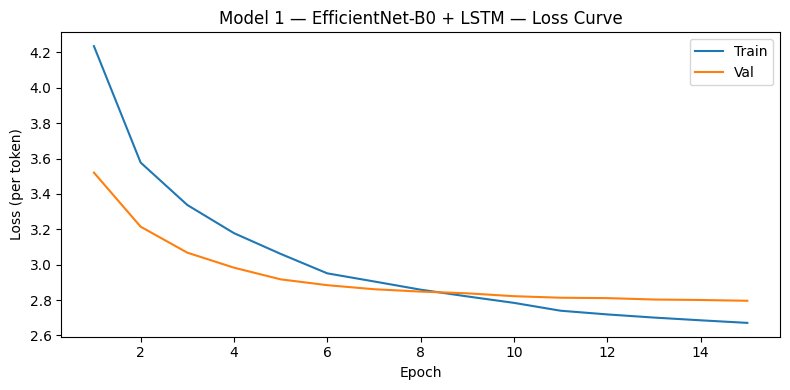

In [15]:
plot_loss_curves(m1_train_losses, m1_val_losses,
                 "Model 1 — EfficientNet-B0 + LSTM — Loss Curve")

### Model 1 BLEU Scores

In [16]:
model1.load_state_dict(torch.load(M1_SAVE_PATH, map_location=DEVICE))

b1, b2, b3, b4 = compute_bleu(test_loader, model1)

print("Model 1 — EfficientNet-B0 + LSTM — Test Set BLEU Scores")
print(f"  BLEU-1: {b1:.4f}")
print(f"  BLEU-2: {b2:.4f}")
print(f"  BLEU-3: {b3:.4f}")
print(f"  BLEU-4: {b4:.4f}")

m1_bleu = {"BLEU-1": b1, "BLEU-2": b2, "BLEU-3": b3, "BLEU-4": b4}

Model 1 — EfficientNet-B0 + LSTM — Test Set BLEU Scores
  BLEU-1: 0.5993
  BLEU-2: 0.4172
  BLEU-3: 0.3019
  BLEU-4: 0.2333


In [17]:
import json
with open(OUTPUT_DIR / "model1_bleu.json", "w") as f:
    json.dump({k: float(v) for k, v in m1_bleu.items()}, f, indent=2)
print("BLEU scores saved.")

BLEU scores saved.


### Model 1 Visual Examples

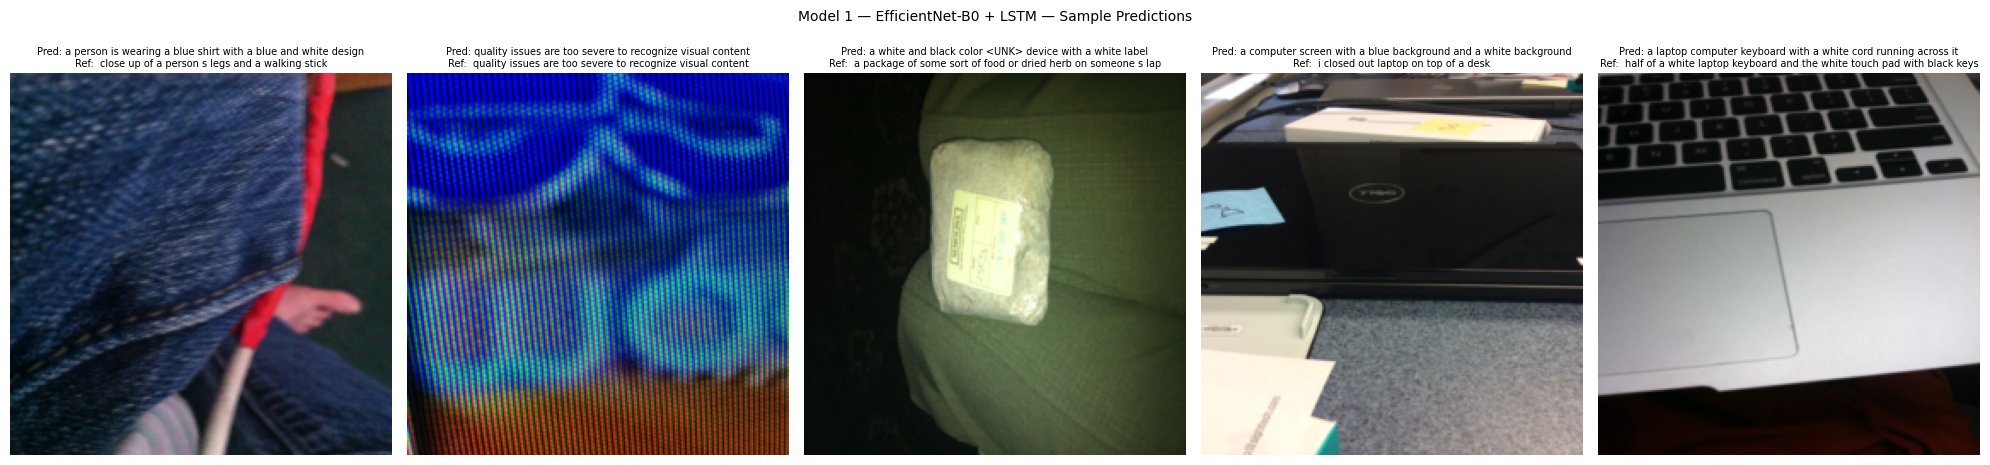

In [18]:
show_predictions(test_dataset, model1,
                 title="Model 1 — EfficientNet-B0 + LSTM — Sample Predictions", n=5)

Group Discussion Summary

## Phase 3: Model 2: Refined Architecture

### Group Discussion Summary
After comparing Model 1 results across the group, we identified the following patterns:

- Models without attention struggled to generate spatially-aware captions, the single
  image vector bottleneck loses regional detail critical for VizWiz's challenging images
- Frozen encoders limited the model's ability to adapt to VizWiz's domain-specific
  characteristics (blurry, dark, poorly-framed photos taken by blind users)
- Greedy decoding produced repetitive, low-diversity captions

### How this informed Model 2
1. Added Bahdanau soft attention, decoder attends to different spatial regions per timestep
2. Partially unfroze EfficientNet-B0 (last 3 blocks) with a lower learning rate
3. Replaced greedy decoding with beam search (beam width=3)
4. Increased embed_dim to 512 and hidden_dim to 1024 for greater capacity


### Encoder (Model 2)

In [19]:
class EfficientNetEncoderAttention(nn.Module):
    """
    EfficientNet-B0 encoder that returns spatial feature maps instead of
    a single pooled vector. The last 3 blocks are unfrozen to allow
    domain adaptation to VizWiz imagery.

    Output shape: (B, num_pixels, encoder_dim)
    where num_pixels = 7*7 = 49 spatial locations.
    """
    def __init__(self, encoder_dim=1280):
        super().__init__()
        base = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.backbone = base.features  # (B, 1280, 7, 7)

        # Freeze all layers first
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Unfreeze last 3 blocks (blocks 6, 7, 8) for domain adaptation
        for block in [self.backbone[6], self.backbone[7], self.backbone[8]]:
            for param in block.parameters():
                param.requires_grad = True

    def forward(self, images):
        x = self.backbone(images)          # (B, 1280, 7, 7)
        B, C, H, W = x.shape
        x = x.permute(0, 2, 3, 1)         # (B, 7, 7, 1280)
        x = x.reshape(B, H * W, C)        # (B, 49, 1280)
        return x

### Bahdanau Attention

In [20]:
class BahdanauAttention(nn.Module):
    """
    Soft attention mechanism (Bahdanau et al., 2015).
    At each decoding step, computes a weighted sum over the 49 spatial
    encoder locations. This allows the decoder to focus on the most
    relevant image regions when generating each word.

    attention_dim: dimensionality of the joint attention space
    """
    def __init__(self, encoder_dim=1280, decoder_dim=1024, attention_dim=512):
        super().__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att    = nn.Linear(attention_dim, 1)
        self.relu        = nn.ReLU()
        self.softmax     = nn.Softmax(dim=1)

    def forward(self, encoder_out, decoder_hidden):
        # encoder_out:    (B, 49, 1280)
        # decoder_hidden: (B, 1024)
        att1 = self.encoder_att(encoder_out)              # (B, 49, attention_dim)
        att2 = self.decoder_att(decoder_hidden).unsqueeze(1)  # (B, 1, attention_dim)
        att  = self.full_att(self.relu(att1 + att2)).squeeze(2)  # (B, 49)
        alpha = self.softmax(att)                         # (B, 49)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)  # (B, 1280)
        return context, alpha

### Attention LSTM Decoder

In [21]:
class AttentionLSTMDecoder(nn.Module):
    """
    LSTM decoder with Bahdanau attention and beam search inference.
    At each step the decoder receives the attended image context
    concatenated with the word embedding as input to the LSTM cell.
    Beam search (width=3) replaces greedy decoding for better caption quality.
    """
    def __init__(self, encoder_dim=1280, embed_dim=512, hidden_dim=1024,
                 vocab_size=VOCAB_SIZE, attention_dim=512, dropout=0.5):
        super().__init__()
        self.attention  = BahdanauAttention(encoder_dim, hidden_dim, attention_dim)
        self.embed      = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm_cell  = nn.LSTMCell(embed_dim + encoder_dim, hidden_dim)
        self.fc_out     = nn.Linear(hidden_dim, vocab_size)
        self.dropout    = nn.Dropout(dropout)
        self.init_h     = nn.Linear(encoder_dim, hidden_dim)
        self.init_c     = nn.Linear(encoder_dim, hidden_dim)
        self.hidden_dim = hidden_dim

    def _init_hidden(self, encoder_out):
        mean_enc = encoder_out.mean(dim=1)          # (B, 1280)
        h = torch.tanh(self.init_h(mean_enc))       # (B, hidden_dim)
        c = torch.tanh(self.init_c(mean_enc))       # (B, hidden_dim)
        return h, c

    def forward(self, encoder_out, captions, lengths):
        B = encoder_out.size(0)
        T = captions.size(1)

        emb    = self.dropout(self.embed(captions))  # (B, T, embed_dim)
        h, c   = self._init_hidden(encoder_out)
        logits = torch.zeros(B, T, VOCAB_SIZE).to(encoder_out.device)

        for t in range(T):
            context, _ = self.attention(encoder_out, h)         # (B, 1280)
            lstm_input = torch.cat([emb[:, t, :], context], dim=1)  # (B, embed+1280)
            h, c       = self.lstm_cell(lstm_input, (h, c))
            logits[:, t, :] = self.fc_out(self.dropout(h))

        return logits

    def beam_search(self, encoder_out, beam_width=3, max_len=MAX_CAPTION_LEN):
        B = encoder_out.size(0)
        results = []

        for b in range(B):
            enc = encoder_out[b].unsqueeze(0)  # (1, 49, 1280)
            h, c = self._init_hidden(enc)

            # Each beam: (score, token_list, h, c)
            beams = [(0.0, [SOS_IDX], h, c)]
            completed = []

            for _ in range(max_len):
                candidates = []
                for score, tokens, h, c in beams:
                    if tokens[-1] == EOS_IDX:
                        completed.append((score, tokens))
                        continue
                    token    = torch.tensor([[tokens[-1]]], device=encoder_out.device)
                    emb      = self.embed(token).squeeze(1)       # (1, embed_dim)
                    context, _ = self.attention(enc, h)
                    lstm_input = torch.cat([emb, context], dim=1)
                    h_new, c_new = self.lstm_cell(lstm_input, (h, c))
                    log_probs = torch.log_softmax(
                        self.fc_out(h_new), dim=1)               # (1, vocab)
                    topk_scores, topk_ids = log_probs[0].topk(beam_width)

                    for i in range(beam_width):
                        candidates.append((
                            score + topk_scores[i].item(),
                            tokens + [topk_ids[i].item()],
                            h_new, c_new
                        ))

                beams = sorted(candidates, key=lambda x: x[0], reverse=True)[:beam_width]
                if all(b[1][-1] == EOS_IDX for b in beams):
                    break

            completed += [(s, t) for s, t, _, _ in beams]
            best = max(completed, key=lambda x: x[0])
            result = [idx for idx in best[1] if idx not in (SOS_IDX, EOS_IDX)]
            results.append(result)

        return results

### Model 2 Assembly

In [22]:
class Model2(nn.Module):
    """
    EfficientNet-B0 (partially unfrozen) + Bahdanau Attention + LSTM decoder
    with beam search. Directly addresses Model 1 weaknesses identified
    in group discussion.
    """
    def __init__(self, encoder_dim=1280, embed_dim=512, hidden_dim=1024,
                 attention_dim=512, vocab_size=VOCAB_SIZE, dropout=0.5):
        super().__init__()
        self.encoder = EfficientNetEncoderAttention(encoder_dim=encoder_dim)
        self.decoder = AttentionLSTMDecoder(
            encoder_dim=encoder_dim, embed_dim=embed_dim,
            hidden_dim=hidden_dim, vocab_size=vocab_size,
            attention_dim=attention_dim, dropout=dropout
        )

    def forward(self, images, captions, lengths):
        encoder_out = self.encoder(images)
        return self.decoder(encoder_out, captions, lengths)

    def generate(self, images, beam_width=3):
        encoder_out = self.encoder(images)
        return self.decoder.beam_search(encoder_out, beam_width=beam_width)


model2 = Model2().to(DEVICE)

total     = sum(p.numel() for p in model2.parameters())
trainable = sum(p.numel() for p in model2.parameters() if p.requires_grad)
print(f"Model 2 — total params:     {total:,}")
print(f"Model 2 — trainable params: {trainable:,}")

Model 2 — total params:     24,386,887
Model 2 — trainable params: 23,535,079


### Train Model 2

In [23]:
M2_EPOCHS    = 15
M2_LR        = 1e-4   # lower LR because encoder is partially unfrozen
M2_SAVE_PATH = OUTPUT_DIR / "model2_best.pt"

m2_train_losses, m2_val_losses = train_model(
    model2, train_loader, val_loader,
    epochs=M2_EPOCHS, lr=M2_LR, save_path=M2_SAVE_PATH
)

Epoch 01/15  train: 4.4340  val: 3.6196
  -> Checkpoint saved (val_loss: 3.6196)


Epoch 02/15  train: 3.6946  val: 3.3036
  -> Checkpoint saved (val_loss: 3.3036)


Epoch 03/15  train: 3.4245  val: 3.1334
  -> Checkpoint saved (val_loss: 3.1334)


Epoch 04/15  train: 3.2377  val: 3.0273
  -> Checkpoint saved (val_loss: 3.0273)


Epoch 05/15  train: 3.0914  val: 2.9630
  -> Checkpoint saved (val_loss: 2.9630)


...

Epoch 11/15  train: 2.6797  val: 2.8672
  -> Checkpoint saved (val_loss: 2.8672)


Epoch 12/15  train: 2.6520  val: 2.8580
  -> Checkpoint saved (val_loss: 2.8580)


Epoch 13/15  train: 2.6303  val: 2.8541
  -> Checkpoint saved (val_loss: 2.8541)


Epoch 14/15  train: 2.6041  val: 2.8507
  -> Checkpoint saved (val_loss: 2.8507)


Epoch 15/15  train: 2.5810  val: 2.8491
  -> Checkpoint saved (val_loss: 2.8491)


### Model 2 Loss Curve

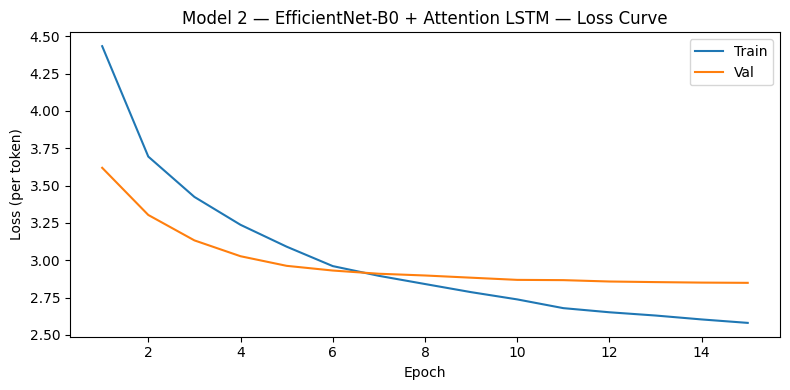

In [24]:
plot_loss_curves(m2_train_losses, m2_val_losses,
                 "Model 2 — EfficientNet-B0 + Attention LSTM — Loss Curve")

### Model 2 BLEU Scores

In [25]:
model2.load_state_dict(torch.load(M2_SAVE_PATH, map_location=DEVICE))

b1, b2, b3, b4 = compute_bleu(test_loader, model2)

print("Model 2 — EfficientNet-B0 + Attention LSTM — Test Set BLEU Scores")
print(f"  BLEU-1: {b1:.4f}")
print(f"  BLEU-2: {b2:.4f}")
print(f"  BLEU-3: {b3:.4f}")
print(f"  BLEU-4: {b4:.4f}")

m2_bleu = {"BLEU-1": b1, "BLEU-2": b2, "BLEU-3": b3, "BLEU-4": b4}

# Save results
import json
with open(OUTPUT_DIR / "model2_bleu.json", "w") as f:
    json.dump({k: float(v) for k, v in m2_bleu.items()}, f, indent=2)
print("BLEU scores saved.")

Model 2 — EfficientNet-B0 + Attention LSTM — Test Set BLEU Scores
  BLEU-1: 0.6152
  BLEU-2: 0.5150
  BLEU-3: 0.4458
  BLEU-4: 0.3990
BLEU scores saved.


### Comparing Both Models

In [26]:
print("=" * 50)
print("  MODEL COMPARISON — Test Set BLEU Scores")
print("=" * 50)
print(f"{'Metric':<12} {'Model 1':>10} {'Model 2':>10} {'Δ':>10}")
print("-" * 50)
for metric in ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]:
    m1 = m1_bleu[metric]
    m2 = m2_bleu[metric]
    delta = m2 - m1
    print(f"{metric:<12} {m1:>10.4f} {m2:>10.4f} {delta:>+10.4f}")
print("=" * 50)

  MODEL COMPARISON — Test Set BLEU Scores
Metric          Model 1    Model 2          Δ
--------------------------------------------------
BLEU-1           0.5993     0.6152    +0.0160
BLEU-2           0.4172     0.5150    +0.0978
BLEU-3           0.3019     0.4458    +0.1439
BLEU-4           0.2333     0.3990    +0.1657


Model 2 Visual Examples

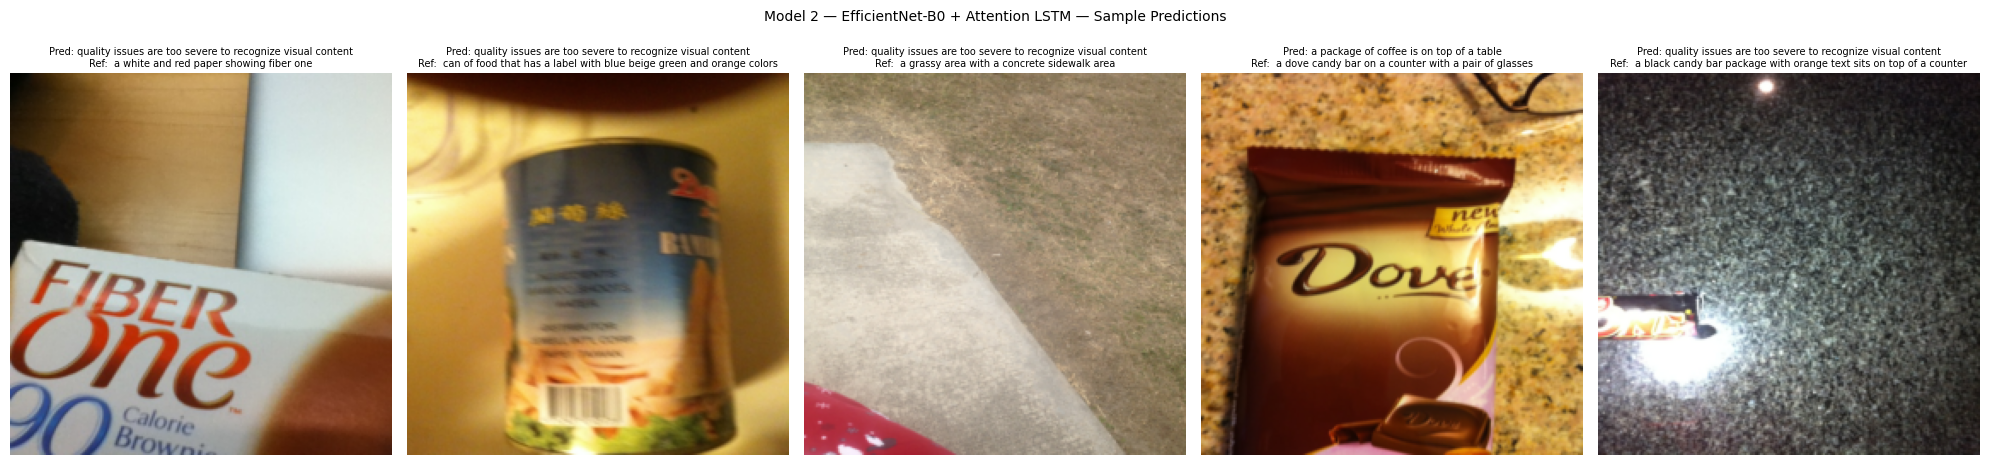

In [27]:
show_predictions(test_dataset, model2,
                 title="Model 2 — EfficientNet-B0 + Attention LSTM — Sample Predictions", n=5)